In [1]:
import numpy as np

# чтобы импорт работал при запуске ноутбука из папки drafts/
import sys
from pathlib import Path
from itertools import combinations, product, permutations

PROJECT_ROOT = Path.cwd().resolve().parents[0]  # .../player_zoom
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.math import DiffDrive

In [2]:
import numpy as np

def gen_taus(N: int, switch_num: int, tau: float, low=0.0, seed=None):
    rng = np.random.default_rng(seed)
    mid = rng.uniform(low, tau, size=(N, switch_num))  # switch_num случайных чисел
    out = np.empty((N, switch_num + 2), dtype=float)
    out[:, 0] = 0.0
    out[:, 1:1+switch_num] = mid
    out[:, -1] = float(tau)
    out = np.sort(out, axis=1)
    out = out[:, 1:] -  out[:, :-1]
    return out

In [3]:
tau = 0.5
switch_num = 2
N = 10
taus_list = gen_taus(N=N, switch_num=switch_num, tau=tau, seed=42)
print(taus_list)
print(taus_list.sum(axis=1))

[[0.21943922 0.1675388  0.11302198]
 [0.34868401 0.08061495 0.07070104]
 [0.04708867 0.4407225  0.01218882]
 [0.38056985 0.0124623  0.10696785]
 [0.06405682 0.16113615 0.27480703]
 [0.18539901 0.27798348 0.03661751]
 [0.32193256 0.08944825 0.08861919]
 [0.11361936 0.10808774 0.2782929 ]
 [0.03190863 0.24538377 0.22270761]
 [0.3158322  0.09798339 0.08618441]]
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


In [4]:
def gen_extreme_controls():
    ret = []
    ret.append(np.array([ 0,  1]))
    ret.append(np.array([ 0, -1]))
    ret.append(np.array([ 1,  0]))
    ret.append(np.array([-1,  0]))
    return ret

extreme_controls = gen_extreme_controls()
extreme_controls

[array([0, 1]), array([ 0, -1]), array([1, 0]), array([-1,  0])]

In [5]:
def are_opposite(v1, v2):
    return np.array_equal(v1, -v2)

def generate_combinations(vectors, length):
    result = []
    for combo in permutations(vectors, length):
        valid = True
        for i in range(len(combo) - 1):
            if are_opposite(combo[i], combo[i+1]):
                valid = False
                break
        if valid:
            result.append(combo)
    return result

control_patterns = generate_combinations(extreme_controls, length=2)

In [6]:
control_patterns[0]

(array([0, 1]), array([1, 0]))

In [7]:
drive = DiffDrive(x=0, y=0, theta=0)
control_pattern = control_patterns[0]
taus = taus_list[0]

def run_pattern(start_state, pattern, taus):
    states = [start_state]
    for i, control in enumerate(pattern):
        next_state = drive.step(control, taus[i])
        states.append(next_state)

    return states

states = run_pattern(start_state=np.array([0, 0]), 
                     pattern=control_pattern,
                     taus=taus)

print(control_pattern)
print(taus)
print(states)


(array([0, 1]), array([1, 0]))
[0.21943922 0.1675388  0.11302198]
[array([0, 0]), array([0.        , 0.        , 0.21943922]), array([0.16352117, 0.03647024, 0.21943922])]


In [8]:
pip install ipympl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\vladi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


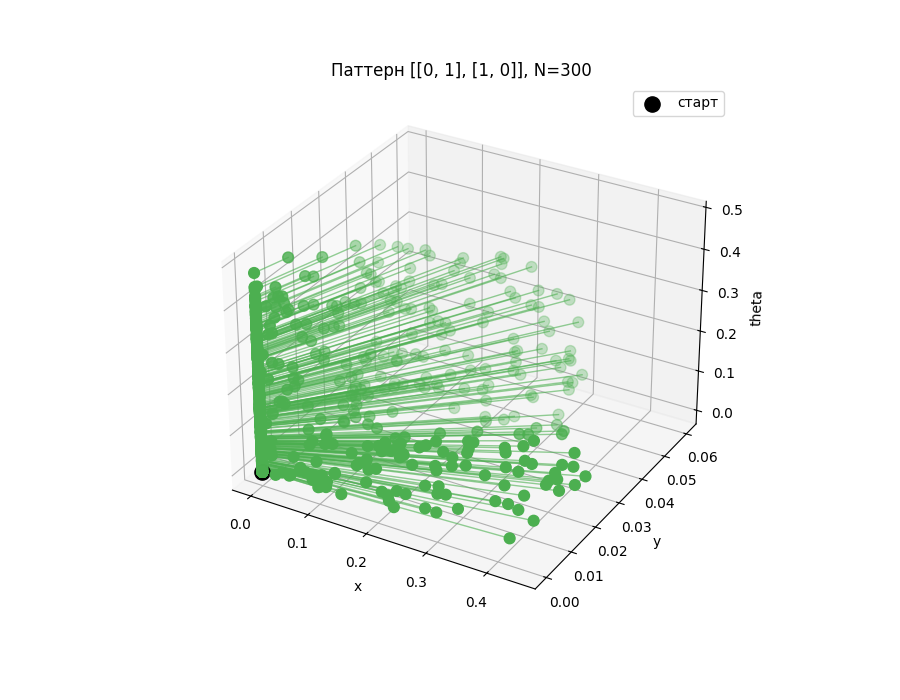

In [11]:
%matplotlib widget

import matplotlib.pyplot as plt

pattern = control_patterns[0]
N = 300
taus_20 = gen_taus(N=N, switch_num=switch_num, tau=tau, seed=42)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for i, taus in enumerate(taus_20):
    drive.reset(0, 0, 0)
    
    states = [np.array([0.0, 0.0, 0.0])]
    for j, control in enumerate(pattern):
        next_state = drive.step(control, taus[j])
        states.append(next_state.copy())
    
    xs = [s[0] for s in states]
    ys = [s[1] for s in states]
    ts = [s[2] for s in states]  # theta
    
    color =  '#4caf50'#plt.cm.tab20(i / N)
    ax.plot(xs, ys, ts, color=color, alpha=0.6, linewidth=1)
    ax.scatter(xs, ys, ts, color=color, s=60, zorder=5,)

ax.scatter([0], [0], [0], color='black', s=120, zorder=10, label='старт')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('theta')
ax.set_title(f"Паттерн {[list(c) for c in pattern]}, N={N}")
ax.legend()
plt.show()
